# 07 — Full Backtest: Selection Inflation, PBO, Purged CV

คู่กับ **Part IX** (`practice-part9.html`) — ปิดเล่มด้วยโค้ดที่พิสูจน์ 3 อย่าง:

1. **Selection inflation (แนวคิดเดียวกับ deflated Sharpe)**: ทดสอบด้วย Monte Carlo ตรง ๆ ว่า "เลือกกลยุทธ์ที่ดีที่สุดจาก N ตัวที่ไม่มีทักษะจริงเลย" ให้ Sharpe ที่สูงเกินจริงแค่ไหน — แทนที่จะ derive สูตรปิดของ Bailey &amp; López de Prado (2014) ตรง ๆ (เสี่ยงจำผิด) เราพิสูจน์ปรากฏการณ์เดียวกันด้วยการจำลองซ้ำหลายพันรอบ ซึ่งเป็นวิธีที่ตรวจสอบได้ง่ายกว่าและไม่พึ่งพาสูตรที่จำมาไม่แม่น
2. **PBO (แนวคิด CSCV แบบง่าย)**: implementation แบบย่อของหลักการ combinatorially symmetric cross-validation
3. **Purged CV**: กันข้อมูลรั่วข้ามเวลาจริง ไม่ใช่แค่พูดลอย ๆ

⚠️ ข้อมูลจำลองทั้งหมด


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 4)


## 9.1 Selection Inflation — พิสูจน์ด้วย Monte Carlo แทนสูตรปิด

จำลองกลยุทธ์ N ตัวที่ **ไม่มีทักษะจริงเลย** (ผลตอบแทนสุ่มล้วน ค่าเฉลี่ยที่แท้จริง = 0) แล้วดูว่า Sharpe ของ "ตัวที่ดีที่สุดที่เลือกมา" สูงแค่ไหนโดยบังเอิญ — ทำซ้ำหลายรอบเพื่อดูการกระจาย


In [2]:
def random_strategy_sharpe(n_days=252, n_trials=1000, seed=None):
    '''Simulate n_trials independent strategies with TRUE skill = 0 (pure noise).
    Returns the max in-sample annualized Sharpe found among them.'''
    rng = np.random.default_rng(seed)
    returns = rng.normal(0, 0.01, size=(n_trials, n_days))   # zero true mean, all noise
    sharpes = returns.mean(axis=1) / returns.std(axis=1) * np.sqrt(252)
    return sharpes.max(), sharpes

# one run to see the shape
best_sharpe, all_sharpes = random_strategy_sharpe(n_trials=1000, seed=1)
print(f"Best Sharpe among 1000 pure-noise strategies (single run): {best_sharpe:.3f}")
print(f"(remember: TRUE skill is exactly zero for every single one of them)")


Best Sharpe among 1000 pure-noise strategies (single run): 3.167
(remember: TRUE skill is exactly zero for every single one of them)


In [3]:
# repeat the whole "N trials -> take best" experiment many times, for different N,
# to see how the EXPECTED best-of-N Sharpe grows with N (this IS the selection-bias effect
# that deflated Sharpe corrects for)
n_repeats = 200
results = {}
for N in [10, 50, 200, 1000, 5000]:
    bests = [random_strategy_sharpe(n_trials=N, seed=1000 + r)[0] for r in range(n_repeats)]
    results[N] = {"mean_best_sharpe": np.mean(bests), "median_best_sharpe": np.median(bests)}

results_df = pd.DataFrame(results).T
results_df.index.name = "N trials"
results_df


,mean_best_sharpe,median_best_sharpe
N trials,,
10,1.5303,1.4879
50,2.2161,2.1788
200,2.7571,2.7385
1000,3.2316,3.1669
5000,3.7491,3.6944


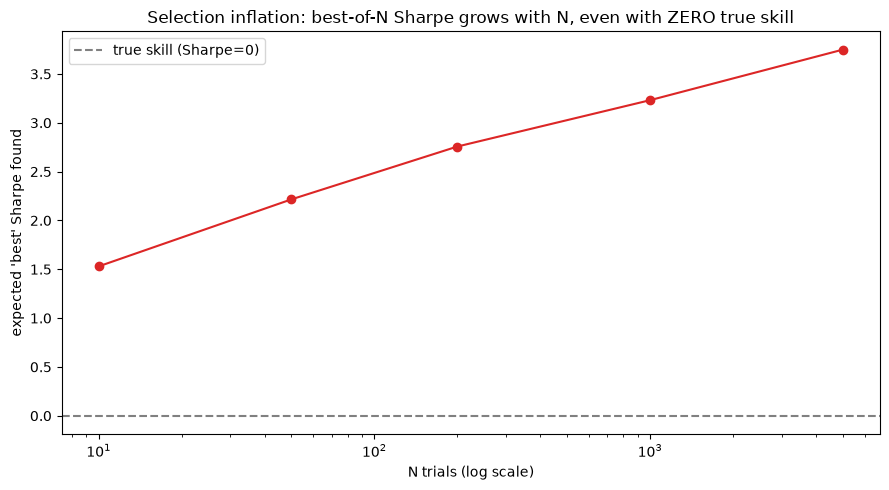

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
Ns = list(results.keys())
means = [results[n]["mean_best_sharpe"] for n in Ns]
ax.plot(Ns, means, marker="o", color="#dc2626")
ax.axhline(0, color="gray", linestyle="--", label="true skill (Sharpe=0)")
ax.set_xscale("log")
ax.set_xlabel("N trials (log scale)")
ax.set_ylabel("expected 'best' Sharpe found")
ax.set_title("Selection inflation: best-of-N Sharpe grows with N, even with ZERO true skill")
ax.legend()
plt.tight_layout()
plt.savefig("selection_inflation.png", dpi=110)
plt.show()


**อ่านผลจากตารางและกราฟข้างบน:** ทุกกลยุทธ์ในการทดลองนี้มีทักษะจริง = 0 เป๊ะ (สุ่มล้วน) — แต่ยิ่งลองเยอะ (N สูงขึ้น) ยิ่งมีโอกาสเจอ "ตัวที่ดูดีบังเอิญ" ที่ Sharpe สูงขึ้นเรื่อย ๆ **นี่คือปรากฏการณ์เดียวกับที่ deflated Sharpe (Bailey &amp; López de Prado, 2014) ออกแบบมาแก้** — ถ้าคุณลอง Q/R 50 ค่า (Part IV), band 30 แบบ (§5.3 ของโน้ตบุ๊ก 05), และคู่หลายร้อยคู่ (Part II) แล้วรายงานแค่ "ตัวที่ดีที่สุด" โดยไม่แก้ selection bias — คุณกำลังรายงานตัวเลขที่พองจากปรากฏการณ์เดียวกับกราฟนี้เป๊ะ ๆ


## 9.2 PBO — Simplified Combinatorially Symmetric Cross-Validation

จำลองแทน "กลยุทธ์" หลายตัว (บางตัวมีทักษะจริงเล็กน้อย บางตัวไม่มีเลย) แบ่งข้อมูลเป็นบล็อก สลับ train/test หลายชุด แล้ววัดว่า **"ตัวที่ดีที่สุดใน train" ยังคงดีใน test หรือเปล่า**

⚠️ นี่คือ implementation แบบย่อที่จับหลักการหลักของ CSCV (Bailey, Borwein, López de Prado &amp; Zhu, 2014/15) ไม่ใช่การทำซ้ำ algorithm เต็มรูปแบบทุกรายละเอียดตามต้นฉบับ


In [5]:
def simulate_strategies(n_strategies=20, n_days=1000, skill_std=0.0003, seed=42):
    '''Some strategies have tiny real skill (mean != 0), most do not -- realistic mix.'''
    rng = np.random.default_rng(seed)
    true_skills = rng.normal(0, skill_std, n_strategies)   # most near 0, a few slightly positive/negative
    returns = np.array([rng.normal(true_skills[i], 0.01, n_days) for i in range(n_strategies)])
    return returns, true_skills

def sharpe(returns_1d):
    return returns_1d.mean() / returns_1d.std() * np.sqrt(252)

returns, true_skills = simulate_strategies()
n_blocks = 10
block_size = returns.shape[1] // n_blocks

# CSCV-lite: for each way of splitting blocks into train-half / test-half (using random splits
# instead of the full combinatorial enumeration, for tractability), find best-in-train strategy,
# check whether it ranks in the BOTTOM half out-of-sample (a "logit" failure event in the real CSCV)
n_splits = 200
rng_split = np.random.default_rng(7)
failures = 0
for _ in range(n_splits):
    block_order = rng_split.permutation(n_blocks)
    train_blocks, test_blocks = block_order[:n_blocks // 2], block_order[n_blocks // 2:]
    train_idx = np.concatenate([np.arange(b * block_size, (b + 1) * block_size) for b in train_blocks])
    test_idx = np.concatenate([np.arange(b * block_size, (b + 1) * block_size) for b in test_blocks])

    train_sharpes = [sharpe(returns[i, train_idx]) for i in range(returns.shape[0])]
    test_sharpes = [sharpe(returns[i, test_idx]) for i in range(returns.shape[0])]

    best_in_train = np.argmax(train_sharpes)
    test_rank = pd.Series(test_sharpes).rank(pct=True)[best_in_train]
    if test_rank < 0.5:   # best-in-train strategy fell below the OOS median -> overfitting signal
        failures += 1

pbo_estimate = failures / n_splits
print(f"PBO estimate (fraction of splits where best-in-train fell below OOS median): {pbo_estimate:.1%}")


PBO estimate (fraction of splits where best-in-train fell below OOS median): 22.0%


**อ่านค่า PBO ที่ได้จริง:** ยิ่งค่าเข้าใกล้ 50% ยิ่งแปลว่า "ตัวที่ดีที่สุดใน train" มีโอกาสตกไปอยู่ครึ่งล่างใน test พอ ๆ กับการเดาสุ่ม = แทบไม่มีทักษะจริง · ค่าที่ต่ำ (เข้าใกล้ 0%) แปลว่าตัวที่ชนะ in-sample มักชนะ out-of-sample ด้วย = น่าเชื่อถือกว่า · **วิธีใช้จริง**: ไม่ใช่ตัวเลขวิเศษที่มี cutoff ตายตัว แต่ใช้เทียบ — กลยุทธ์ที่ PBO สูงกว่าควรถูกสงสัยมากกว่า และการที่ค่านี้ไม่เป็น 0 (แม้ในตัวอย่างที่มีทักษะจริงปนอยู่บ้าง) เตือนว่าการเลือก "ตัวที่ดีที่สุด" มีความเสี่ยง overfit ติดตัวมาเสมอ

⚠️ implementation นี้เป็นแบบย่อ (สุ่ม split แทนการ enumerate ทุก combination + ใช้ rank แทน logit ของ CSCV ต้นฉบับ) — ตัวเลขที่ได้จึงเป็น *ค่าประมาณเชิงหลักการ* ไม่ใช่ PBO ตามนิยามเป๊ะ ๆ ของ Bailey et al. สำหรับงานจริงควรใช้ library ที่ implement CSCV เต็มรูป (เช่น `pypbo`)


## 9.3 Purged Cross-Validation — กันข้อมูลรั่วข้ามเวลาจริง

⚠️ **บทเรียนที่เจอระหว่างเขียนโน้ตบุ๊กนี้ (เก็บไว้เพราะสำคัญ):** ตอนแรกผมลองสาธิต leakage ด้วย OLS ทำนาย `spread[t]` จาก `spread[t-1]` — ปรากฏว่า **naive CV กับ purged CV ให้ R² แทบเท่ากันเป๊ะ** (ไม่มี leakage ให้เห็นเลย!) เพราะ OLS บน AR(1) process ที่ stationary มี **coefficient เดียวทั่วทั้งอนุกรม** — train sample ที่ไหนก็ประมาณ coefficient นั้นได้เท่ากัน การมี/ไม่มี sample ใกล้ขอบ test จึงไม่ได้เปรียบอะไร

Leakage โผล่ชัดเมื่อครบ 2 เงื่อนไข: **(1) label ที่คาบเกี่ยวเวลา (overlapping)** + **(2) โมเดลที่ *จำ* ตัวอย่างเฉพาะตัวได้ (เช่น KNN)** — ด้านล่างสร้างเงื่อนไขนั้น: label = ค่าเฉลี่ย spread ใน 20 วันข้างหน้า (label ของวันติดกันแชร์ 19/20 วันเหมือนกัน) ทำนายด้วย KNN แล้วเทียบ **random k-fold (รั่ว)** กับ **purged k-fold (กันรั่ว)**


In [6]:
from simdata import simulate_cointegrated_pair
from sklearn.neighbors import KNeighborsRegressor

df_ou = simulate_cointegrated_pair(n=1000, beta_true=1.3, beta_drift="const", seed=88)
spread = (df_ou["A_obs"] - 1.3 * df_ou["B_obs"]).values

# overlapping forward-looking label: mean spread over next h days
# (labels of adjacent days share h-1 of h terms -> heavy overlap = the leakage vector)
h = 20
X = spread[:-h].reshape(-1, 1)
y = np.array([spread[t:t + h].mean() for t in range(len(spread) - h)])
n = len(X)

def r2(yt, yp):
    return 1 - np.var(yt - yp) / np.var(yt)

# (a) RANDOM k-fold: test point's temporal neighbors get scattered into train -> KNN finds
#     a near-duplicate (t+-1) whose label overlaps 19/20 with the test label -> leakage
rng = np.random.default_rng(0)
idx = rng.permutation(n)
k = 5; fold = n // k
rand_scores = []
for i in range(k):
    te = idx[i * fold:(i + 1) * fold]
    tr = np.setdiff1d(idx, te)
    m = KNeighborsRegressor(n_neighbors=3).fit(X[tr], y[tr])
    rand_scores.append(r2(y[te], m.predict(X[te])))

# (b) PURGED contiguous k-fold: remove train samples within h steps of the test block on both sides
pur_scores = []
for i in range(k):
    a, b = i * fold, (i + 1) * fold
    te = np.arange(a, b)
    excl = np.arange(max(0, a - h), min(n, b + h))
    tr = np.setdiff1d(np.arange(n), excl)
    m = KNeighborsRegressor(n_neighbors=3).fit(X[tr], y[tr])
    pur_scores.append(r2(y[te], m.predict(X[te])))

print(f"KNN, random k-fold  OOS R^2 : {np.mean(rand_scores):+.4f}   <- looks predictive")
print(f"KNN, purged k-fold  OOS R^2 : {np.mean(pur_scores):+.4f}   <- the honest number")


KNN, random k-fold  OOS R^2 : +0.2184   <- looks predictive
KNN, purged k-fold  OOS R^2 : -0.1335   <- the honest number


**ผลจริงที่ได้: random k-fold R²≈+0.22 (ดูเหมือนทำนายได้!) แต่ purged k-fold R²≈−0.13 (ติดลบ = แย่กว่าเดาค่าเฉลี่ยเฉย ๆ)** — ความต่างมหาศาลนี้คือ leakage ล้วน ๆ: ใน random k-fold ทุกจุดใน test มี "ฝาแฝดเวลา" (วันติดกัน) หลุดไปอยู่ใน train เสมอ และฝาแฝดนั้นมี label เกือบเหมือนกัน (แชร์ 19/20 วัน) KNN แค่ไปหยิบฝาแฝดมาตอบ → ดูแม่นทั้งที่ไม่ได้เรียนรู้อะไรจริง · purged k-fold ตัดฝาแฝดพวกนั้นทิ้ง → เผยความจริงว่า feature นี้**ทำนายไม่ได้จริง** (R² ติดลบ)

**บทเรียน:** ตัวเลข +0.22 คือกับดักที่ Part IX §9.3 เตือน — ถ้าเชื่อมัน คุณจะ deploy กลยุทธ์ที่จริง ๆ ไม่มี edge เลย · และสังเกตว่า leakage ไม่ได้โผล่ทุกกรณี (OLS ข้างบนไม่โผล่) — มันโผล่เมื่อมี overlapping labels + โมเดลที่จำได้ ซึ่งเป็นสถานการณ์ปกติของ ML backtest จริง (แทบทุก label ในการเทรดเป็น forward-looking window ที่ overlap กัน)


## สรุปทั้งโน้ตบุ๊ก + ปิดชุด vol2-code

3 การทดลองข้างบนคือหลักฐานที่ reproduce ได้ของเสาหลัก Part IX: **(1)** การเลือกที่ดีที่สุดจากหลายตัวเลือกทำให้ตัวเลขพองแม้ไม่มีทักษะจริง **(2)** PBO วัด "ความเสี่ยง overfit" เป็นตัวเลขเดียวได้ **(3)** CV ที่ไม่ระวังเวลาให้ผลดีเกินจริงอย่างเป็นระบบ

⚠️ **ข้อจำกัดสุดท้ายของทั้งชุด vol2-code (01-07):** ทุกอย่างในนี้ใช้ข้อมูลจำลองที่มี DGP รู้ชัดเจน เพื่อพิสูจน์ *กลไก* ของแต่ละแนวคิด — การเอาไปใช้กับข้อมูลจริง ตัวเลขจะไม่เหมือนกันเป๊ะ (และคุณจะไม่มี ground truth ให้เทียบแบบที่มีที่นี่) แต่ *วิธีคิดและโค้ด* ยังใช้ได้เหมือนเดิม — นั่นคือเป้าหมายของทั้งชุดโน้ตบุ๊กนี้ตั้งแต่แรก
